# Segmentación por crecimiento de regiones

In [6]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
from skimage.segmentation import flood

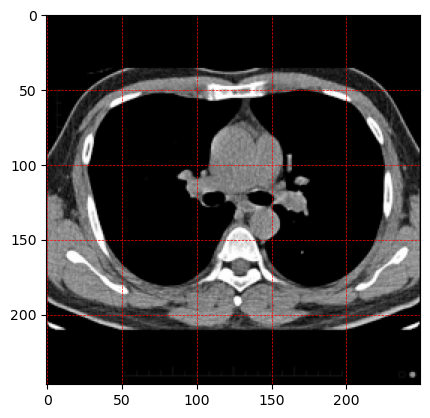

In [ ]:
imChest = cv2.imread("images/CHEST.png", cv2.IMREAD_GRAYSCALE)
plt.imshow(imChest, cmap='gray', vmin=0, vmax=255)
plt.grid(color='red', linestyle='--', linewidth=0.5)

*Segmentación manual (paint)*

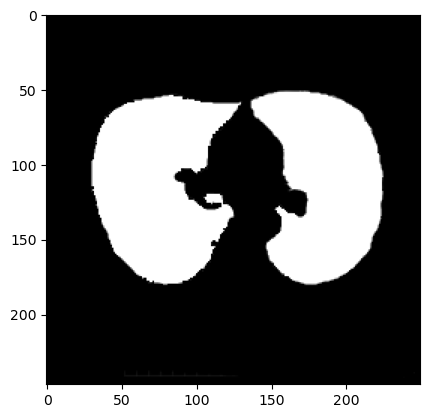

In [21]:
maskImg = cv2.imread("images/mask.png", 0)
plt.imshow(maskImg, cmap='gray', vmin=0, vmax=255)

*Segmentación por algoritmo de crecimiento*

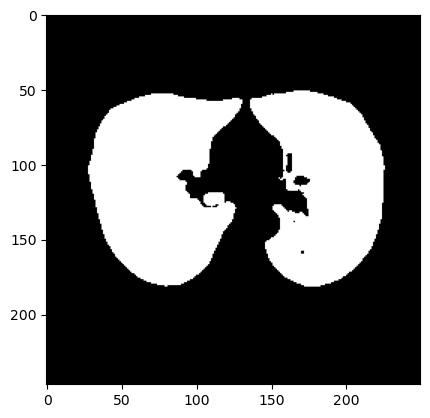

In [19]:
#Selección de la semilla
semilla_izq = (100, 50)  # Adjust based on your image
semilla_der = (100, 200)

# Definición de la variación de intensidad permitida
tolerancia= 20

# Apply region growing using flood
mascara_izq = flood(imChest, semilla_izq, tolerance=tolerancia)
mascara_der = flood(imChest, semilla_der, tolerance=tolerancia)

mascara = mascara_izq | mascara_der

plt.imshow(mascara, cmap='gray')

Lo que podemos ver es que la segmentación usando el algoritmo de crecimiento es mucho más precisa, los bordes se ven mucho más definidos, sin embargo hay unos huecos en la imágen que pueden deberse a que hay objetos que no hacen parte del pulmón o a que están en tonos más claros de lo que deberían.

In [ ]:
def dice_coefficient(mask1, mask2):
    # Convertir a booleanos
    m1 = np.asarray(mask1).astype(bool)
    m2 = np.asarray(mask2).astype(bool)
    
    # Calcular la intersección (píxeles comunes)
    intersection = np.logical_and(m1, m2).sum()
    
    # Aplicar la fórmula
    return (2. * intersection) / (m1.sum() + m2.sum())

# Calcular el valor
resultado_dice = dice_coefficient(maskImg, mascara)
print(f"El Coeficiente de Sorensen-Dice es: {resultado_dice:.4f}")

El Coeficiente de Sorensen-Dice es: 0.9697


Lo que nos dice el coeficiente es que las áreas son muy parecidas, y el trabajo que se hizo en paint fue bueno, sin embargo, tomó bastante tiempo y el algoritmo lo hizo con unos mejores bordes y más rapido.